In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Set plotting style
sns.set_style('whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load Dataset

df = pd.read_csv('../data/raw/loan_data.csv')

# Display first 5 rows
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
# Check dataset dimensions

print("Shape of Dataset:", df.shape)


Shape of Dataset: (614, 13)


In [5]:
# Display column names

df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [6]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [7]:
# Check missing values

df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
# Missing Values Percentage

missing_values = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': round((df.isnull().sum()/len(df))*100, 2)
})

missing_values

,Missing Values,Percentage (%)
Loan_ID,0,0.00
Gender,13,2.12
Married,3,0.49
Dependents,15,2.44
Education,0,0.00
Self_Employed,32,5.21
ApplicantIncome,0,0.00
CoapplicantIncome,0,0.00
LoanAmount,22,3.58
Loan_Amount_Term,14,2.28


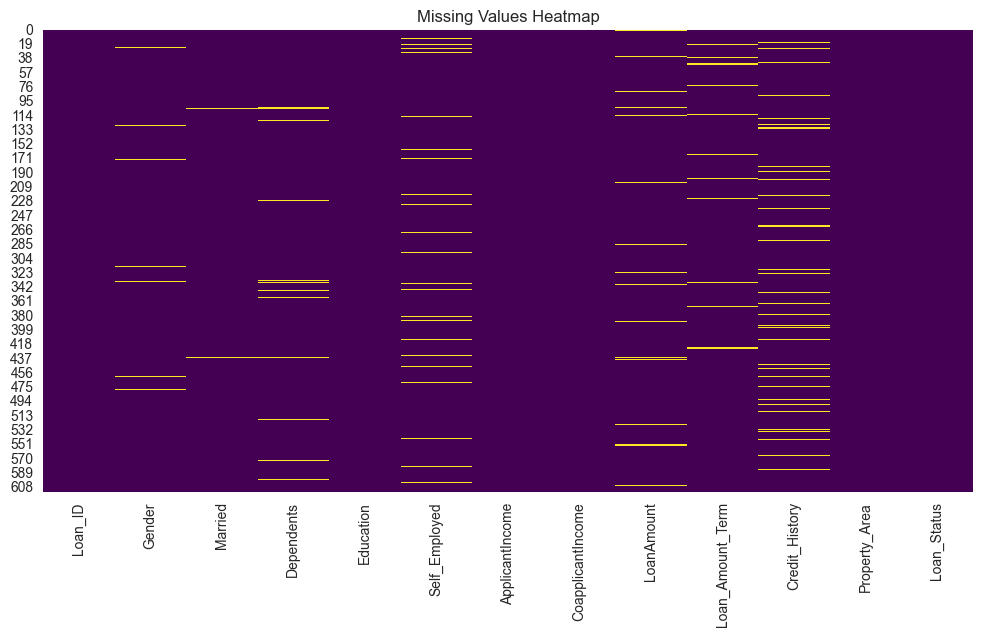

In [9]:
# Visualize Missing Values

plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis')

plt.title('Missing Values Heatmap')
plt.show()

In [10]:
# Filling missing values

# Categorical columns -> Mode

df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

df['Married'].fillna(df['Married'].mode()[0], inplace=True)

df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)

df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

# Numerical columns -> Median

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)

# Credit History -> Mode

df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

print("Missing values handled successfully!")

Missing values handled successfully!


C:\Users\Mahathi Vaka\AppData\Local\Temp\ipykernel_36156\691667751.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
C:\Users\Mahathi Vaka\AppData\Local\Temp\ipykernel_36156\691667751.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series throu

In [11]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [12]:
# Fill missing values

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df['Married'] = df['Married'].fillna(df['Married'].mode()[0])

df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])

df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(
    df['Loan_Amount_Term'].median()
)

df['Credit_History'] = df['Credit_History'].fillna(
    df['Credit_History'].mode()[0]
)

print("Missing values handled successfully!")

Missing values handled successfully!


In [13]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [14]:
# Check duplicate records

print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


In [15]:
# Create Total Income column

df['Total_Income'] = (
    df['ApplicantIncome'] +
    df['CoapplicantIncome']
)

df[['ApplicantIncome',
    'CoapplicantIncome',
    'Total_Income']].head()

,ApplicantIncome,CoapplicantIncome,Total_Income
0,5849,0.0,5849.0
1,4583,1508.0,6091.0
2,3000,0.0,3000.0
3,2583,2358.0,4941.0
4,6000,0.0,6000.0


In [16]:
# Create EMI Feature

df['EMI'] = (
    df['LoanAmount'] /
    df['Loan_Amount_Term']
)

df[['LoanAmount',
    'Loan_Amount_Term',
    'EMI']].head()

,LoanAmount,Loan_Amount_Term,EMI
0,128.0,360.0,0.355556
1,128.0,360.0,0.355556
2,66.0,360.0,0.183333
3,120.0,360.0,0.333333
4,141.0,360.0,0.391667


In [17]:
# Create Debt-to-Income Ratio

df['DTI_Ratio'] = (
    df['LoanAmount'] /
    df['Total_Income']
)

df[['LoanAmount',
    'Total_Income',
    'DTI_Ratio']].head()

,LoanAmount,Total_Income,DTI_Ratio
0,128.0,5849.0,0.021884
1,128.0,6091.0,0.021015
2,66.0,3000.0,0.022000
3,120.0,4941.0,0.024287
4,141.0,6000.0,0.023500
